# 03 — Validation et modélisation
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 3** du sujet : mise en place d'une validation cohérente avec
l'ordre temporel, comparaison d'au moins deux familles de modèles supplémentaires (Random Forest et
Gradient Boosting via XGBoost), réglage des hyperparamètres et choix du seuil de décision.

Les features utilisées sont **identiques à la baseline** (notebook 02) : ce notebook compare des
familles de modèles à jeu de variables constant. Le feature engineering (notebook 04) sera évalué
en plus, sur le meilleur modèle retenu ici.

## 0. Configuration et chargement des données

In [1]:
import sys, os
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

from src.config import RANDOM_STATE, NUM_COLS, CAT_COLS
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, build_preprocessor, make_pipeline
from src.evaluation import evaluate, plot_confusion, threshold_curve, plot_threshold_curve
from src.model_io import save_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

print(f"Date de coupure : {split_date.date()}")
print(f"Train interne : {X_tr_p.shape[0]} lignes | Validation : {X_val_p.shape[0]} lignes")

Date de coupure : 2024-11-28
Train interne : 6400 lignes | Validation : 1600 lignes


## 3.1 Validation croisée temporelle pour le réglage des hyperparamètres

Le split simple train/validation du notebook 02 sert à **comparer les modèles entre eux** de façon
stable (même jeu de validation pour tous). Mais pour **régler les hyperparamètres** de chaque modèle, un
unique split est fragile : le score obtenu peut dépendre du hasard de cette coupure précise plutôt que
d'un vrai bon réglage.

On utilise donc `TimeSeriesSplit` de scikit-learn **à l'intérieur du train interne** (`X_tr`, qui exclut
déjà la validation finale) : c'est une validation croisée à fenêtre glissante qui respecte l'ordre
chronologique — chaque fold d'entraînement précède toujours son fold de test, jamais l'inverse. Cela
donne une estimation plus robuste du F1-score pendant la recherche d'hyperparamètres, tout en conservant
la contrainte temporelle exigée par le sujet à chaque étape.

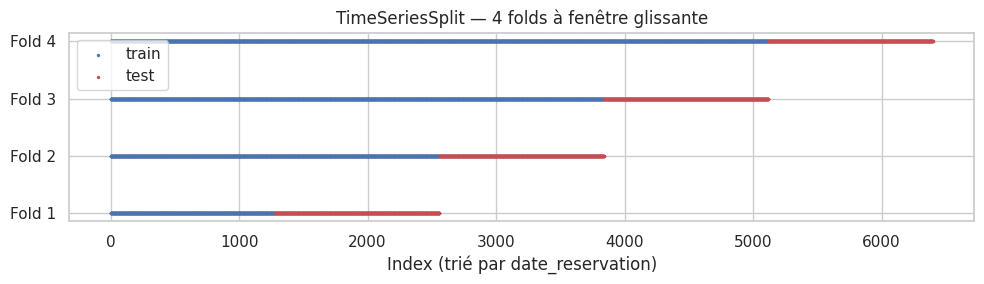

In [2]:
tscv = TimeSeriesSplit(n_splits=4)

# Vérification visuelle du découpage temporel des folds
fig, ax = plt.subplots(figsize=(10, 3))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_tr_p)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c="#4C72B0", s=2, label="train" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c="#C44E52", s=2, label="test" if i == 0 else None)
ax.set_yticks(range(4))
ax.set_yticklabels([f"Fold {i+1}" for i in range(4)])
ax.set_xlabel("Index (trié par date_reservation)")
ax.set_title("TimeSeriesSplit — 4 folds à fenêtre glissante")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3.2 Modèle 2 — Random Forest

Premher modèle arborescent : robuste aux outliers et aux relations non linéaires identifiées en EDA
(ex : `delai_reservation_jours`), sans nécessiter de transformation manuelle. On règle un petit nombre
d'hyperparamètres clés par recherche aléatoire (`RandomizedSearchCV`), avec `class_weight="balanced"`
pour la même raison que la baseline.

In [3]:
rf_param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 6, 8, 12, None],
    "model__min_samples_leaf": [1, 3, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_pipe = make_pipeline(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=15, scoring="f1", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
rf_search.fit(X_tr_p, y_tr)

print("Meilleurs hyperparamètres RF :", rf_search.best_params_)
print(f"F1 moyen (CV temporelle, train interne) : {rf_search.best_score_:.4f}")

Meilleurs hyperparamètres RF : {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 6}
F1 moyen (CV temporelle, train interne) : 0.4569


In [4]:
rf_best = rf_search.best_estimator_
val_proba_rf = rf_best.predict_proba(X_val_p)[:, 1]
rf_results, val_pred_rf = evaluate(y_val, val_proba_rf, threshold=0.5, label="Random Forest")

print("=== Random Forest (seuil 0.5) ===")
for k, v in rf_results.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.4f}")
print()
print(classification_report(y_val, val_pred_rf, target_names=["Maintenue", "Annulée"]))

=== Random Forest (seuil 0.5) ===
seuil     : 0.5000
f1        : 0.4579
precision : 0.3547
recall    : 0.6457
roc_auc   : 0.6530

              precision    recall  f1-score   support

   Maintenue       0.81      0.57      0.67      1171
     Annulée       0.35      0.65      0.46       429

    accuracy                           0.59      1600
   macro avg       0.58      0.61      0.56      1600
weighted avg       0.69      0.59      0.61      1600



## 3.3 Modèle 3 — XGBoost (Gradient Boosting)

Deuxième famille de modèle arborescent, mais avec un principe d'apprentissage différent (boosting
séquentiel plutôt que bagging) : chaque arbre corrige les erreurs des précédents, ce qui capture souvent
mieux les interactions fines entre variables. On utilise `scale_pos_weight` (ratio négatifs/positifs)
comme équivalent de `class_weight="balanced"` pour XGBoost.

In [5]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_param_dist = {
    "model__n_estimators": [150, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_pipe = make_pipeline(XGBClassifier(
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    eval_metric="logloss", n_jobs=-1,
))

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=15, scoring="f1", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
xgb_search.fit(X_tr_p, y_tr)

print("Meilleurs hyperparamètres XGB :", xgb_search.best_params_)
print(f"F1 moyen (CV temporelle, train interne) : {xgb_search.best_score_:.4f}")

scale_pos_weight = 2.907


Meilleurs hyperparamètres XGB : {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}
F1 moyen (CV temporelle, train interne) : 0.4625


In [6]:
xgb_best = xgb_search.best_estimator_
val_proba_xgb = xgb_best.predict_proba(X_val_p)[:, 1]
xgb_results, val_pred_xgb = evaluate(y_val, val_proba_xgb, threshold=0.5, label="XGBoost")

print("=== XGBoost (seuil 0.5) ===")
for k, v in xgb_results.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.4f}")
print()
print(classification_report(y_val, val_pred_xgb, target_names=["Maintenue", "Annulée"]))

=== XGBoost (seuil 0.5) ===
seuil     : 0.5000
f1        : 0.4619
precision : 0.3561
recall    : 0.6573
roc_auc   : 0.6565

              precision    recall  f1-score   support

   Maintenue       0.82      0.56      0.67      1171
     Annulée       0.36      0.66      0.46       429

    accuracy                           0.59      1600
   macro avg       0.59      0.61      0.56      1600
weighted avg       0.69      0.59      0.61      1600



## 3.4 Comparaison des modèles

On ré-entraîne rapidement la baseline (identique au notebook 02) pour comparer les trois modèles côte à
côte, **sur le même jeu de validation**, condition indispensable à une comparaison valide (cf. README
§4).

In [7]:
baseline_pipe = make_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
baseline_pipe.fit(X_tr_p, y_tr)
val_proba_baseline = baseline_pipe.predict_proba(X_val_p)[:, 1]
baseline_results, _ = evaluate(y_val, val_proba_baseline, threshold=0.5, label="Régression logistique — baseline")

comparison = pd.DataFrame([baseline_results, rf_results, xgb_results]).set_index("modele")
comparison[["seuil", "f1", "precision", "recall", "roc_auc"]].round(4)

,seuil,f1,precision,recall,roc_auc
modele,,,,,
Régression logistique — baseline,0.5,0.4537,0.3609,0.6107,0.6532
Random Forest,0.5,0.4579,0.3547,0.6457,0.6530
XGBoost,0.5,0.4619,0.3561,0.6573,0.6565


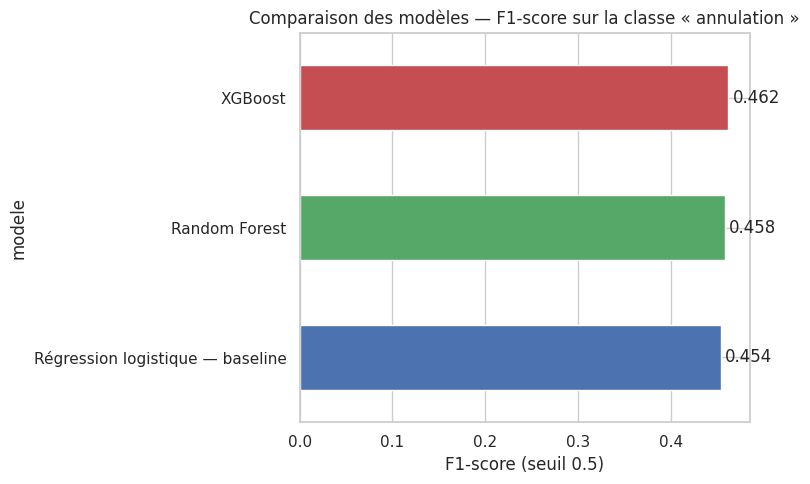

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison["f1"].plot(kind="barh", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlabel("F1-score (seuil 0.5)")
ax.set_title("Comparaison des modèles — F1-score sur la classe « annulation »")
for i, v in enumerate(comparison["f1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 3.5 Choix du seuil de décision

Le seuil par défaut (0.5) n'est pas nécessairement optimal pour le F1-score, surtout avec des classes
déséquilibrées. On recherche, pour chaque modèle, le seuil qui **maximise le F1 sur la validation** —
en gardant à l'esprit que ce choix a un coût métier (arbitrage faux positifs / faux négatifs, discuté en
détail au notebook 05).

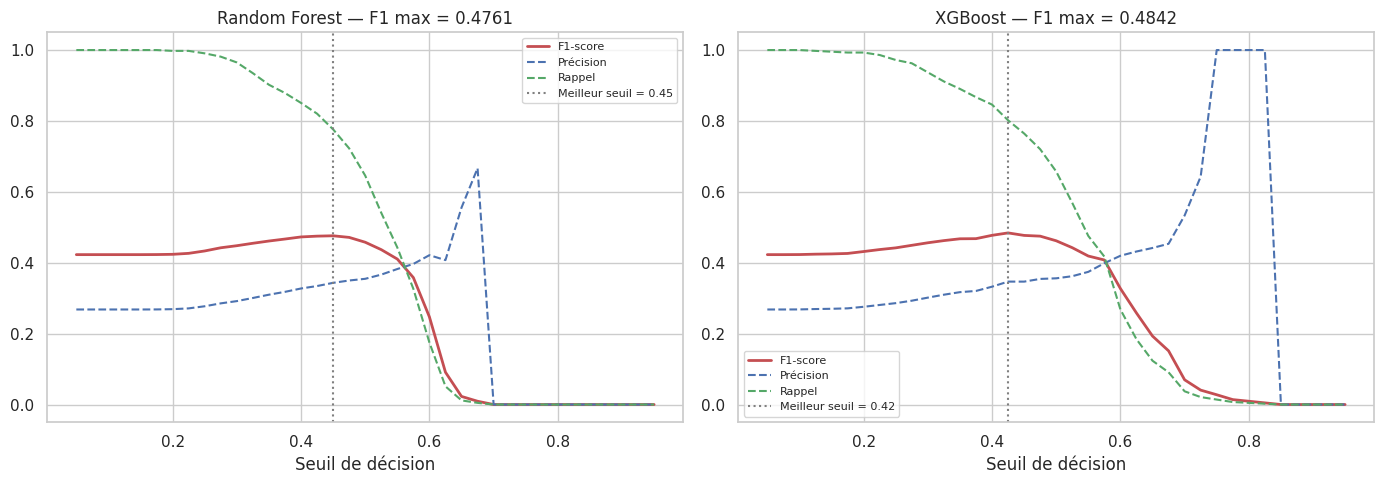

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (proba, label) in zip(axes, [(val_proba_rf, "Random Forest"), (val_proba_xgb, "XGBoost")]):
    thresholds, f1s, precisions, recalls = threshold_curve(y_val, proba)
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds, f1s, label="F1-score", linewidth=2, color="#C44E52")
    ax.plot(thresholds, precisions, label="Précision", linestyle="--", color="#4C72B0")
    ax.plot(thresholds, recalls, label="Rappel", linestyle="--", color="#55A868")
    ax.axvline(best_t, color="gray", linestyle=":", label=f"Meilleur seuil = {best_t:.2f}")
    ax.set_title(f"{label} — F1 max = {f1s.max():.4f}")
    ax.set_xlabel("Seuil de décision")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
results_at_best_threshold = []
for proba, label in [(val_proba_baseline, "Régression logistique — baseline"),
                      (val_proba_rf, "Random Forest"),
                      (val_proba_xgb, "XGBoost")]:
    thresholds, f1s, _, _ = threshold_curve(y_val, proba)
    best_t = thresholds[np.argmax(f1s)]
    res, _ = evaluate(y_val, proba, threshold=best_t, label=label)
    results_at_best_threshold.append(res)

comparison_best = pd.DataFrame(results_at_best_threshold).set_index("modele")
comparison_best[["seuil", "f1", "precision", "recall", "roc_auc"]].round(4)

,seuil,f1,precision,recall,roc_auc
modele,,,,,
Régression logistique — baseline,0.300,0.4727,0.3183,0.9184,0.6532
Random Forest,0.450,0.4761,0.3433,0.7762,0.6530
XGBoost,0.425,0.4842,0.3468,0.8019,0.6565


## 3.6 Sélection du modèle retenu pour la suite

**Constat :** les modèles arborescents (Random Forest, XGBoost) dépassent la baseline, ce qui est
attendu — ils capturent les relations non linéaires (ex : `delai_reservation_jours`, cf. EDA §1.6) et
les interactions entre variables qu'une régression logistique linéaire ne peut représenter qu'imparfaitement
sans feature engineering explicite.

On retient le modèle le plus performant (F1 le plus élevé au seuil optimal) comme **modèle de travail**
pour la suite du projet : le feature engineering (notebook 04) sera évalué en mesurant le gain de F1
qu'il apporte à ce modèle, et l'analyse d'erreurs (notebook 05) portera sur ses prédictions.

Le choix final entre Random Forest et XGBoost pour la **soumission** (notebook 06) ne se fera qu'après
le feature engineering, une fois que l'on saura quel modèle en tire le plus grand bénéfice.

In [11]:
best_model_name = comparison_best["f1"].idxmax()
print("Modèle retenu (F1 le plus élevé, seuil optimal) :", best_model_name)
print(comparison_best.loc[best_model_name])

# Sauvegarde des deux modèles arborescents (réutilisés au notebook 04 pour mesurer
# le gain du feature engineering sur des bases comparables) ainsi que la baseline.
save_model(baseline_pipe, "baseline_logreg", metadata=baseline_results)
save_model(rf_best, "random_forest_v1", metadata={**rf_results, "best_params": rf_search.best_params_})
save_model(xgb_best, "xgboost_v1", metadata={**xgb_results, "best_params": xgb_search.best_params_})

Modèle retenu (F1 le plus élevé, seuil optimal) : XGBoost
seuil        0.425000
f1           0.484166
precision    0.346774
recall       0.801865
roc_auc      0.656479
Name: XGBoost, dtype: float64
Modèle sauvegardé : /home/claude/atlantic-haven/artifacts/baseline_logreg.joblib
Modèle sauvegardé : /home/claude/atlantic-haven/artifacts/random_forest_v1.joblib
Modèle sauvegardé : /home/claude/atlantic-haven/artifacts/xgboost_v1.joblib


PosixPath('/home/claude/atlantic-haven/artifacts/xgboost_v1.joblib')